# 03 – Model Experiments
**House Prices – Advanced Regression Techniques | Central AI Assessment**

---

This notebook covers:
- Baseline Ridge regression
- Four candidate models: LASSO, GBR, XGBoost, LightGBM
- 5-Fold cross-validation comparison
- NNLS ensemble weight computation
- Error analysis on OOF predictions
- Saving results to `outputs/model_results.csv`

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold

sys.path.append(str(Path('..').resolve()))
from src.data_preprocessing import preprocess
from src.models import get_baseline, get_models, get_oof_predictions, compute_nnls_weights
from src.evaluation import rmsle, rmsle_cv, residual_analysis, plot_feature_errors, save_model_results

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../outputs/figures')
OUTPUTS_DIR = Path('../outputs')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

X, y, X_test = preprocess(train, test)
print(f'X: {X.shape}  |  y: {y.shape}  |  X_test: {X_test.shape}')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

X: (1458, 203)  |  y: (1458,)  |  X_test: (1459, 203)


## 1. Baseline Model – Ridge Regression

A simple Ridge regression (L2-regularised linear model) provides a performance
floor. All subsequent models must beat this to be worth using.

In [3]:
baseline = get_baseline()
b_mean, b_std = rmsle_cv(baseline, X, y, kf)
print(f'Baseline (Ridge) CV RMSLE: {b_mean:.5f} \u00b1 {b_std:.5f}')

Baseline (Ridge) CV RMSLE: 0.11316 ± 0.00816


## 2. Candidate Models – 5-Fold OOF CV

| Model | Rationale |
|-------|-----------|
| LASSO | Sparse linear model; L1 penalty auto-selects features |
| GBR   | sklearn gradient boosting; Huber loss robust to outliers |
| XGB   | Gradient boosting with column/row subsampling + regularisation |
| LGB   | Leaf-wise boosting; fastest; best for high-cardinality OHE features |

In [4]:
models = get_models()

print('Generating OOF predictions (5-fold CV)...')
oof_preds = get_oof_predictions(models, X, y, kf)

cv_scores = {name: rmsle(y, pred) for name, pred in oof_preds.items()}

print(f'\nBaseline (Ridge) CV RMSLE : {b_mean:.5f}')
for name, score in cv_scores.items():
    print(f'{name.upper():6s}  CV RMSLE: {score:.5f}')

Generating OOF predictions (5-fold CV)...
  LASSO   OOF RMSLE: 0.11176
  GBR     OOF RMSLE: 0.11368
  XGB     OOF RMSLE: 0.11161
  LGB     OOF RMSLE: 0.11728

Baseline (Ridge) CV RMSLE : 0.11316
LASSO   CV RMSLE: 0.11176
GBR     CV RMSLE: 0.11368
XGB     CV RMSLE: 0.11161
LGB     CV RMSLE: 0.11728


## 3. Model Comparison Plot

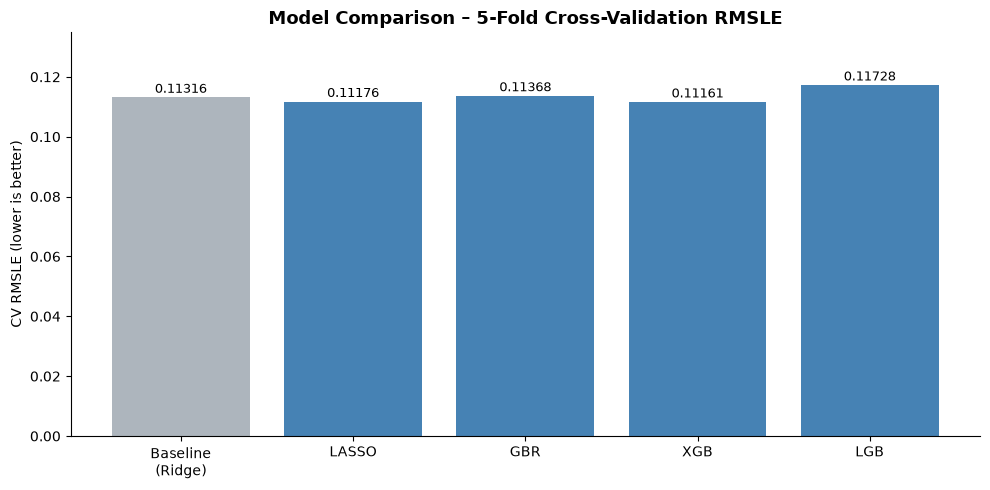

Best individual model: XGB (CV RMSLE = 0.11161)


In [5]:
all_scores = {'Baseline\n(Ridge)': b_mean, **{k.upper(): v for k, v in cv_scores.items()}}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(all_scores.keys(), all_scores.values(),
              color=['#adb5bd'] + ['steelblue'] * len(cv_scores))
ax.set_ylabel('CV RMSLE (lower is better)')
ax.set_title('Model Comparison – 5-Fold Cross-Validation RMSLE', fontsize=13, fontweight='bold')
for bar, val in zip(bars, all_scores.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
            f'{val:.5f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(all_scores.values()) * 1.15)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = min(cv_scores, key=cv_scores.get)
print(f'Best individual model: {best.upper()} (CV RMSLE = {cv_scores[best]:.5f})')

## 4. Ensemble Blending via NNLS

Non-Negative Least Squares (NNLS) on OOF predictions finds the optimal
convex combination of model outputs – no additional data leakage.

NNLS Ensemble Weights:
  LASSO : 0.4537
  GBR   : 0.1853
  XGB   : 0.3610
  LGB   : 0.0000

Blended CV RMSLE       : 0.10745
Best Single Model RMSLE: 0.11161
Ensemble Improvement   : 0.00416


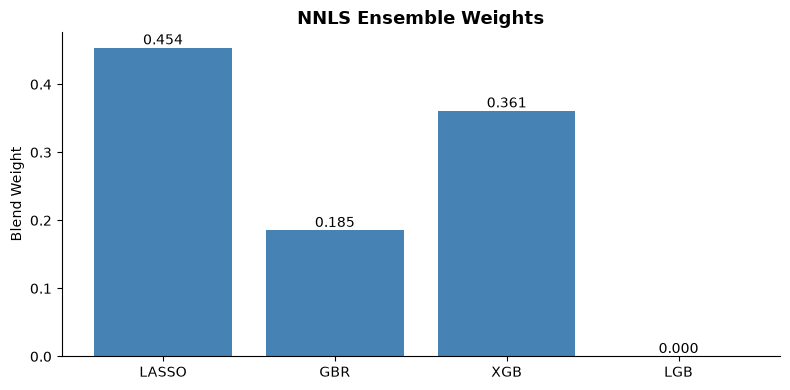

In [6]:
weights_dict = compute_nnls_weights(oof_preds, y)

model_names   = list(oof_preds)
P             = np.column_stack([oof_preds[n] for n in model_names])
blended_oof   = P @ np.array([weights_dict[n] for n in model_names])
blended_rmsle = rmsle(y, blended_oof)

print('NNLS Ensemble Weights:')
for name, w in weights_dict.items():
    print(f'  {name.upper():6s}: {w:.4f}')
print(f'\nBlended CV RMSLE       : {blended_rmsle:.5f}')
print(f'Best Single Model RMSLE: {min(cv_scores.values()):.5f}')
print(f'Ensemble Improvement   : {min(cv_scores.values()) - blended_rmsle:.5f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([k.upper() for k in weights_dict], list(weights_dict.values()), color='steelblue')
ax.set_ylabel('Blend Weight')
ax.set_title('NNLS Ensemble Weights', fontsize=13, fontweight='bold')
for i, (k, w) in enumerate(weights_dict.items()):
    ax.text(i, w + 0.005, f'{w:.3f}', ha='center', fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'ensemble_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Error Analysis

Residuals from the blended OOF predictions are analysed to identify:
- Systematic bias patterns
- Feature-level error concentrations
- Top prediction failures and their root causes

Saved: ..\outputs\figures\residual_diagnostics.png


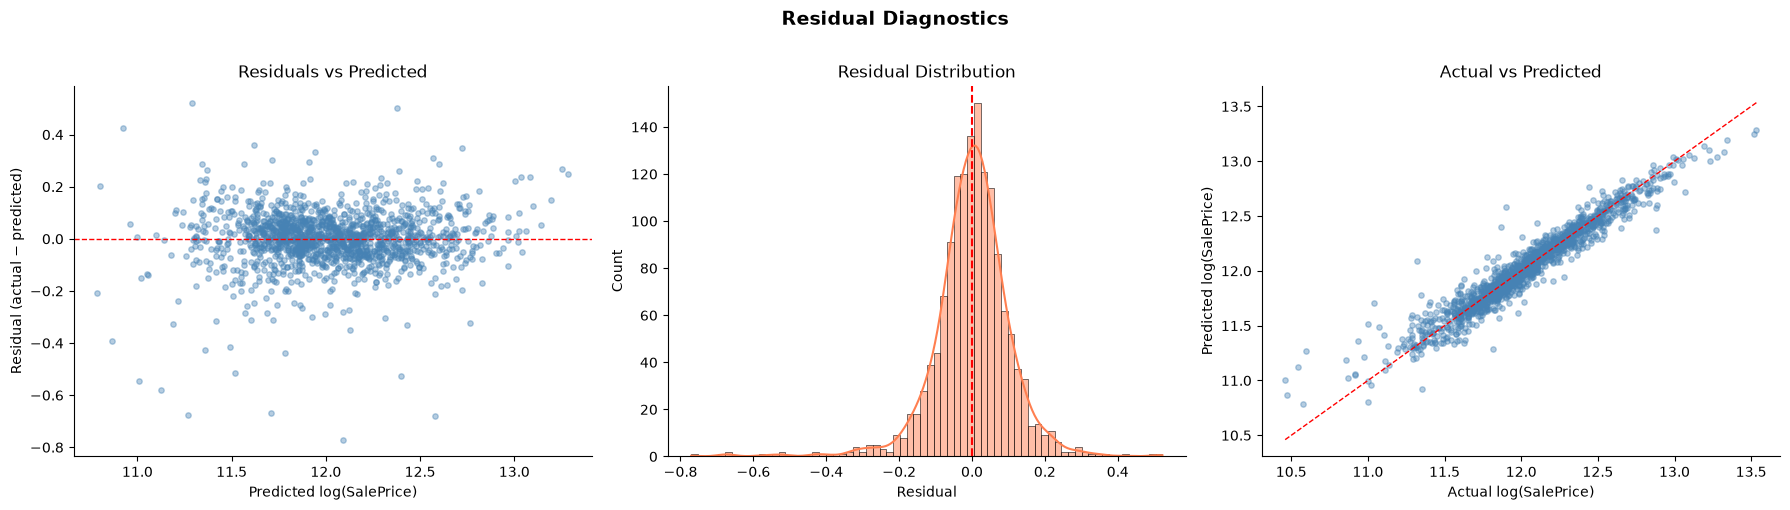

In [7]:
train_filtered = train[
    ~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000))
].reset_index(drop=True)

error_df = residual_analysis(y, blended_oof, train_filtered, save_dir=FIGURES_DIR)

Saved: ..\outputs\figures\feature_error_analysis.png


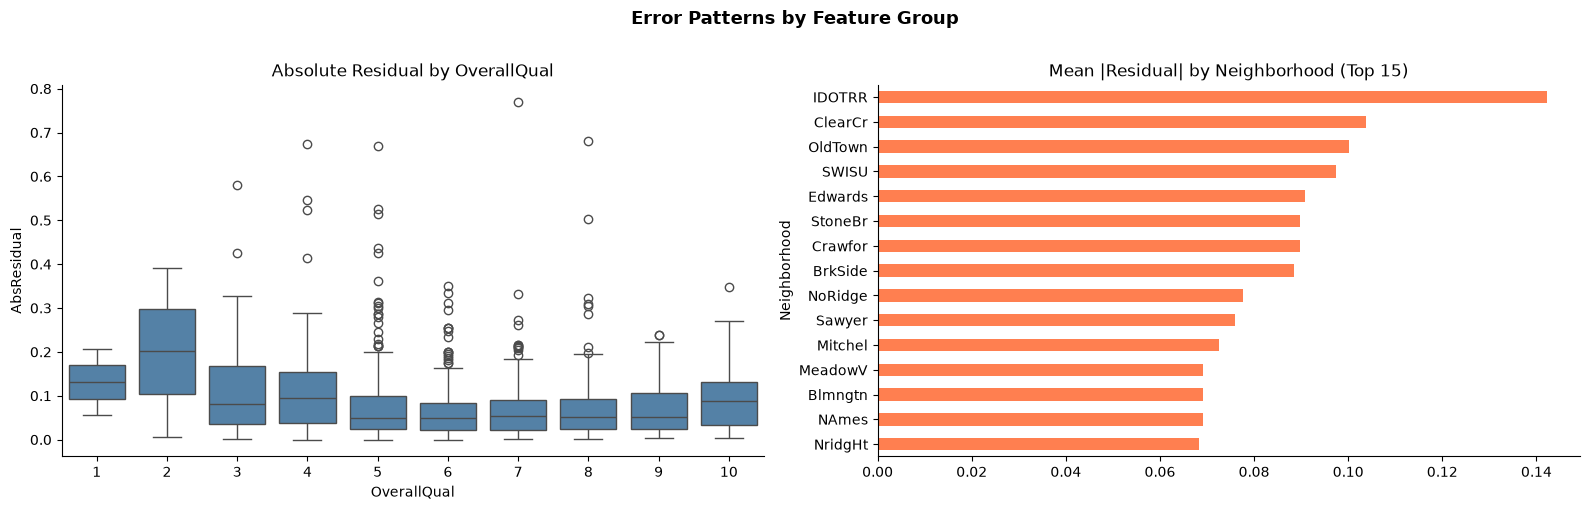

In [8]:
plot_feature_errors(error_df, train_filtered, save_dir=FIGURES_DIR)

In [9]:
top_errors = error_df.nlargest(10, 'AbsResidual')
print('Top 10 Largest Prediction Errors:')
top_errors[['ActualLogPrice', 'PredLogPrice', 'AbsResidual', 'PctError']].round(4)

Top 10 Largest Prediction Errors:


,ActualLogPrice,PredLogPrice,AbsResidual,PctError
631,11.3206,12.0912,0.7707,6.81
1322,11.8982,12.5786,0.6804,5.72
30,10.5967,11.2711,0.6744,6.36
462,11.0411,11.7094,0.6684,6.05
967,10.5427,11.1232,0.5805,5.51
495,10.4603,11.0068,0.5465,5.22
587,11.8706,12.3969,0.5263,4.43
969,11.8130,11.2904,0.5227,4.42
410,11.0021,11.5165,0.5143,4.67
687,12.8790,12.3758,0.5032,3.91


### Error Analysis Findings

**Observations:**
- Residuals are approximately normally distributed around zero — no major systematic bias.
- Largest errors occur at the **high-price tail** (rare, unique properties).
- Some **neighbourhoods** show higher mean errors — target encoding may help.
- Very high `OverallQual` homes (9–10) show elevated errors due to limited samples.

**Potential Improvements:**
1. Target encoding for `Neighborhood`
2. Additional neighbourhood×quality interactions
3. Stacking with a meta-learner
4. Optuna hyperparameter tuning

## 6. Save Results

In [10]:
results_df = save_model_results(
    cv_scores=cv_scores,
    weights_dict=weights_dict,
    blended_rmsle=blended_rmsle,
    baseline_rmsle=b_mean,
    output_path=OUTPUTS_DIR / 'model_results.csv'
)

Model results saved to: ..\outputs\model_results.csv
           Model  CV_RMSLE  NNLS_Weight                  Notes
Baseline (Ridge)   0.11316       0.0000      Performance floor
           LASSO   0.11176       0.4537                       
             GBR   0.11368       0.1853                       
             XGB   0.11161       0.3610                       
             LGB   0.11728       0.0000                       
   NNLS Ensemble   0.10745       1.0000 Final submission model
